``` KNN Classification```

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



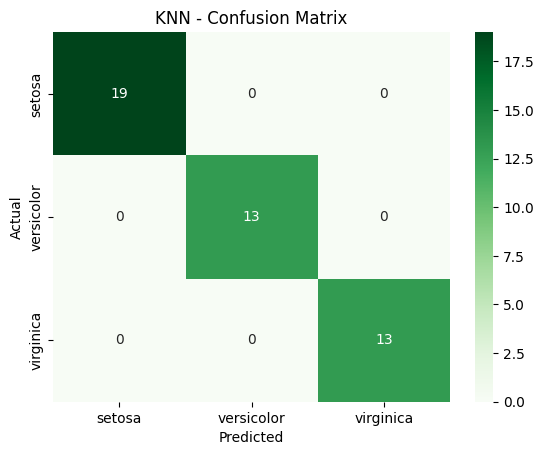

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Greens", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


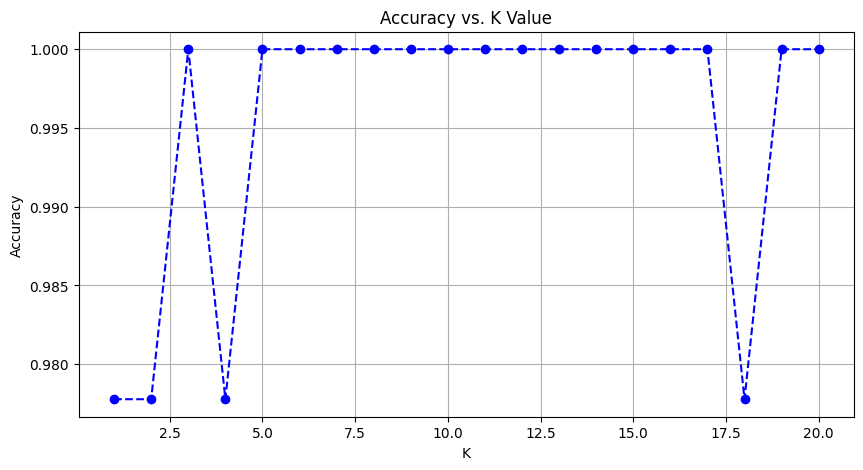

In [ ]:
error_rates = []
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred_k = model.predict(X_test)
    error = 1 - accuracy_score(y_test, pred_k)
    error_rates.append(error)
    accuracies.append(accuracy_score(y_test, pred_k))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), accuracies, color='blue', marker='o', linestyle='dashed')
plt.title("Accuracy vs. K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


```KNN Regression```

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)
y_pred = knn_reg.predict(X_test)

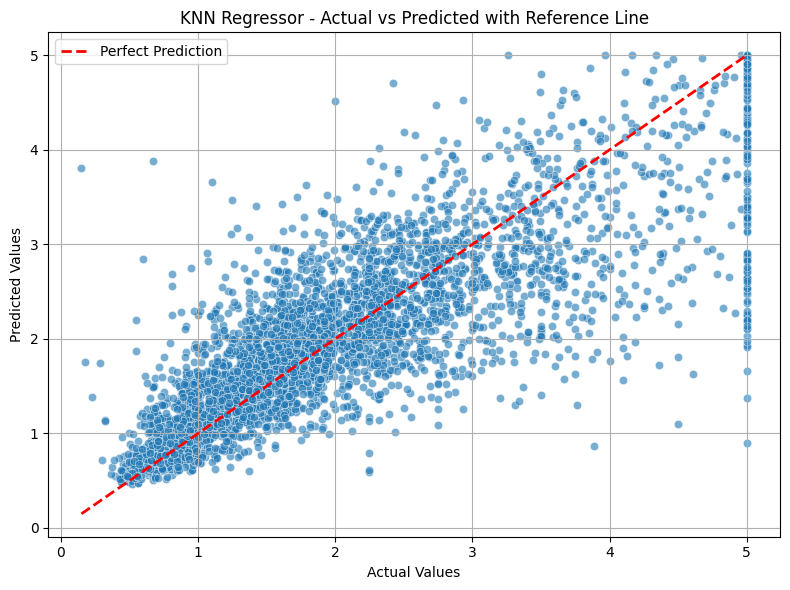

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming y_test and y_pred are your actual and predicted values
# Changed y_pred_knn to y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Plotting the perfect prediction line
max_val = max(max(y_test), max(y_pred)) # Changed y_pred_knn to y_pred
min_val = min(min(y_test), min(y_pred)) # Changed y_pred_knn to y_pred
plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('KNN Regressor - Actual vs Predicted with Reference Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

```Hyper parameter Tunning```

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor # Import KNeighborsRegressor

# Define the parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Use KNeighborsRegressor instead of KNeighborsClassifier
grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error') # Changed to regressor and appropriate scoring
grid_reg.fit(X_train, y_train)

# Best parameters and accuracy
print("Best Parameters:", grid_reg.best_params_)
print("Best Cross-Validated MSE:", grid_reg.best_score_) # Changed accuracy to MSE for regressor

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Cross-Validated MSE: -0.3608964017272985


In [11]:
param_grid_reg = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid_reg, cv=5, scoring='r2')
grid_reg.fit(X_train, y_train)

# Best parameters and R2 score
print("Best Parameters:", grid_reg.best_params_)
print("Best Cross-Validated R2 Score:", grid_reg.best_score_)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best Cross-Validated R2 Score: 0.7300012758297105


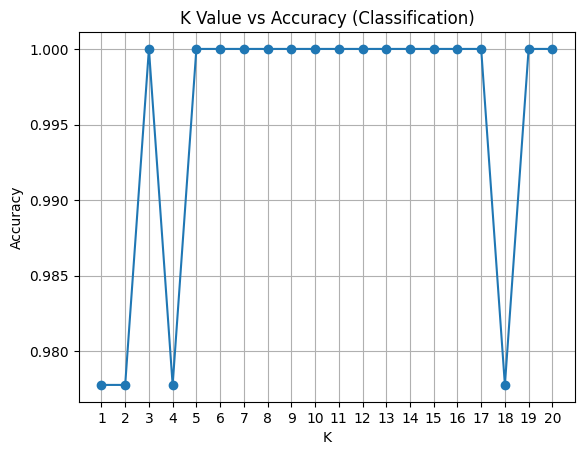

In [13]:
#Visualizing How k Affects Accuracy
accuracies = []
k_values = range(1, 21)

# Load the Iris dataset for classification
from sklearn.datasets import load_iris
iris = load_iris()
X_class = iris.data
y_class = iris.target

# Split dataset for classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

# Feature scaling for classification
scaler = StandardScaler()
X_train_class = scaler.fit_transform(X_train_class)
X_test_class = scaler.transform(X_test_class)


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Use the classification data for training
    knn.fit(X_train_class, y_train_class)
    y_pred_k = knn.predict(X_test_class)
    acc = accuracy_score(y_test_class, y_pred_k)
    accuracies.append(acc)

# Plotting
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title("K Value vs Accuracy (Classification)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

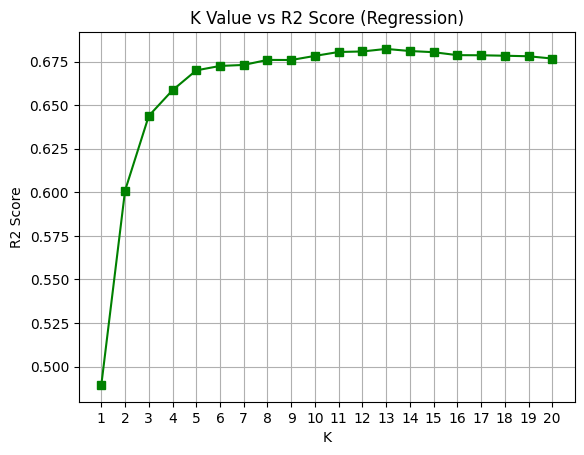

In [14]:
#Visualizing How k Affects R2 Score
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    r2 = r2_score(y_test, y_pred_k)
    r2_scores.append(r2)

# Plotting
plt.plot(k_values, r2_scores, marker='s', color='green')
plt.title("K Value vs R2 Score (Regression)")
plt.xlabel("K")
plt.ylabel("R2 Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

| **k Value**     | **Effect**                                              |
|-----------------|---------------------------------------------------------|
| Small (1–3)     | Low bias, high variance – prone to overfitting          |
| Medium (5–10)   | Balanced bias-variance tradeoff                         |
| High (>15)      | High bias, low variance – risk of underfitting          |
